### Setup

In [34]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from vit_pytorch import ViT
import os

# ==== CONFIG ====
DATA_DIR = "/Users/jacobanderson/Documents/Spring 2025/CompE696/compe-696/OTB100/Biker"  # Change this to your dataset root
BATCH_SIZE = 16
EPOCHS = 10
IMG_SIZE = 224
TRAIN_SPLIT = 0.9
LEARNING_RATE = 3e-4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Transform

In [35]:
# ==== TRANSFORMS ====
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

### Load data

In [36]:
# ==== LOAD DATA ====
full_dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
class_names = full_dataset.classes
train_len = int(TRAIN_SPLIT * len(full_dataset))
test_len = len(full_dataset) - train_len
train_set, test_set = random_split(full_dataset, [train_len, test_len])

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)


### ViT Model

In [37]:
# ==== VIT MODEL ====
model = ViT(
    image_size=IMG_SIZE,
    patch_size=16,
    num_classes=len(class_names),
    dim=512,
    depth=6,
    heads=8,
    mlp_dim=1024,
    dropout=0.1,
    emb_dropout=0.1
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), LEARNING_RATE)

### Training

In [38]:
# ==== TRAINING ====
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    print(f"[Epoch {epoch+1}] Loss: {total_loss:.4f}, Train Acc: {100 * correct / total:.2f}%")

[Epoch 1] Loss: 0.0000, Train Acc: 100.00%
[Epoch 2] Loss: 0.0000, Train Acc: 100.00%
[Epoch 3] Loss: 0.0000, Train Acc: 100.00%
[Epoch 4] Loss: 0.0000, Train Acc: 100.00%
[Epoch 5] Loss: 0.0000, Train Acc: 100.00%
[Epoch 6] Loss: 0.0000, Train Acc: 100.00%
[Epoch 7] Loss: 0.0000, Train Acc: 100.00%
[Epoch 8] Loss: 0.0000, Train Acc: 100.00%
[Epoch 9] Loss: 0.0000, Train Acc: 100.00%
[Epoch 10] Loss: 0.0000, Train Acc: 100.00%


### Testing

In [39]:
# ==== TESTING ====
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

print(f"🎯 Test Accuracy: {100 * correct / total:.2f}%")

🎯 Test Accuracy: 100.00%


### Object tracking: Prediction vs. Ground Truth

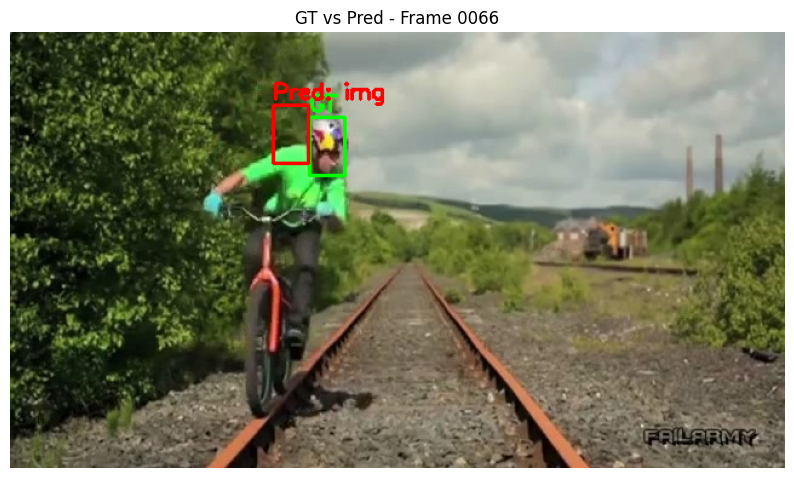

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
import torch

# === Config ===
seq_name = "Biker"
base_path = "/Users/jacobanderson/Documents/Spring 2025/CompE696/OTB100"
frame_idx = 65  # 0 = 0001.jpg

img_folder = f"{base_path}/{seq_name}/img"
gt_path = f"{base_path}/{seq_name}/groundtruth_rect.txt"
frame_number = str(frame_idx + 1).zfill(4)
frame_path = f"{img_folder}/{frame_number}.jpg"

# === Load Ground Truth Box ===
with open(gt_path, "r") as f:
    lines = f.readlines()
    x_gt, y_gt, w_gt, h_gt = map(int, lines[frame_idx].strip().split(','))

# === Load Frame ===
frame = cv2.imread(frame_path)
if frame is None:
    raise FileNotFoundError(f"Could not load {frame_path}")
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# === Preprocess transform ===
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# === Sliding Window Search ===
search_range = 30  # how far to search around the GT box
step = 10
max_score = -float('inf')
pred_box = None
pred_label = "?"

model.eval()

# Loop over candidate regions
for dx in range(-search_range, search_range+1, step):
    for dy in range(-search_range, search_range+1, step):
        x = max(0, x_gt + dx)
        y = max(0, y_gt + dy)
        w, h = w_gt, h_gt

        if y+h > frame_rgb.shape[0] or x+w > frame_rgb.shape[1]:
            continue  # skip out-of-bounds

        crop = frame_rgb[y:y+h, x:x+w]
        input_tensor = transform(crop).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            score = torch.max(output).item()
            label_idx = torch.argmax(output, dim=1).item()

        if score > max_score:
            max_score = score
            pred_box = (x, y, w, h)
            pred_label = class_names[label_idx]

# === Draw Ground Truth and Predicted Box ===
x, y, w, h = pred_box

cv2.rectangle(frame_rgb, (x_gt, y_gt), (x_gt + w_gt, y_gt + h_gt), (0, 255, 0), 2)  # GT in green
cv2.putText(frame_rgb, "GT", (x_gt, y_gt - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

cv2.rectangle(frame_rgb, (x, y), (x + w, y + h), (255, 0, 0), 2)  # Pred in blue
cv2.putText(frame_rgb, f"Pred: {pred_label}", (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

# === Show Image ===
plt.figure(figsize=(10, 8))
plt.imshow(frame_rgb)
plt.title(f"GT vs Pred - Frame {frame_number}")
plt.axis("off")
plt.show()


### Save model

In [ ]:
# ==== SAVE MODEL ====
torch.save(model.state_dict(), "vit_target_recognition.pth")
print("Model saved to vit_target_recognition.pth")